# Company News EDA

Exploratory analysis of `data/raw/finnhub_company_news/`.  
Run `kedro run --pipeline finnhub_company_news` first to populate the data.

**Sections**
1. Load & overview
2. Coverage rate over time (% of universe with ≥1 article per week)
3. Article volume over time
4. Free-tier date distribution per ticker
5. Source breakdown
6. Summary null rate by source
7. Intra-day & day-of-week publication patterns
8. Headline length distribution

In [1]:
from __future__ import annotations

import glob
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/raw/finnhub_company_news")

## 1  Load & Overview

In [2]:
files = sorted(DATA_DIR.glob("*.parquet"))
print(f"Tickers on disk: {len(files)}")

df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True,
)

df["date"] = df["datetime"].dt.normalize()
df["week"] = df["datetime"].dt.to_period("W").dt.start_time
df["month"] = df["datetime"].dt.to_period("M").dt.start_time
df["hour"] = df["datetime"].dt.hour
df["dow"] = df["datetime"].dt.day_name()
df["headline_len"] = df["headline"].str.len()

UNIVERSE_SIZE = len(files)

print(f"Total articles : {len(df):,}")
print(f"Date range     : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Null summaries : {df['summary'].isna().mean():.1%}")
df.dtypes

Tickers on disk: 514


Total articles : 120,274
Date range     : 2018-04-05 → 2026-04-25
Null summaries : 5.0%


article_id               int64
ticker                     str
datetime        datetime64[ms]
headline                   str
summary                    str
source                     str
url                        str
date            datetime64[ms]
week            datetime64[us]
month           datetime64[us]
hour                     int32
dow                        str
headline_len             int64
dtype: object

In [3]:
# Quick shape summary
per_ticker = df.groupby("ticker").size().rename("n_articles")
per_ticker.describe().rename("articles per ticker").to_frame()

,articles per ticker
count,514.000000
mean,233.996109
std,15.113475
min,96.000000
25%,232.000000
50%,237.000000
75%,241.000000
max,250.000000


## 2  Coverage Rate Over Time

**Definition**: on a given week, what share of the S&P 500 universe has at least one article?  
100 % = every ticker has coverage that week.

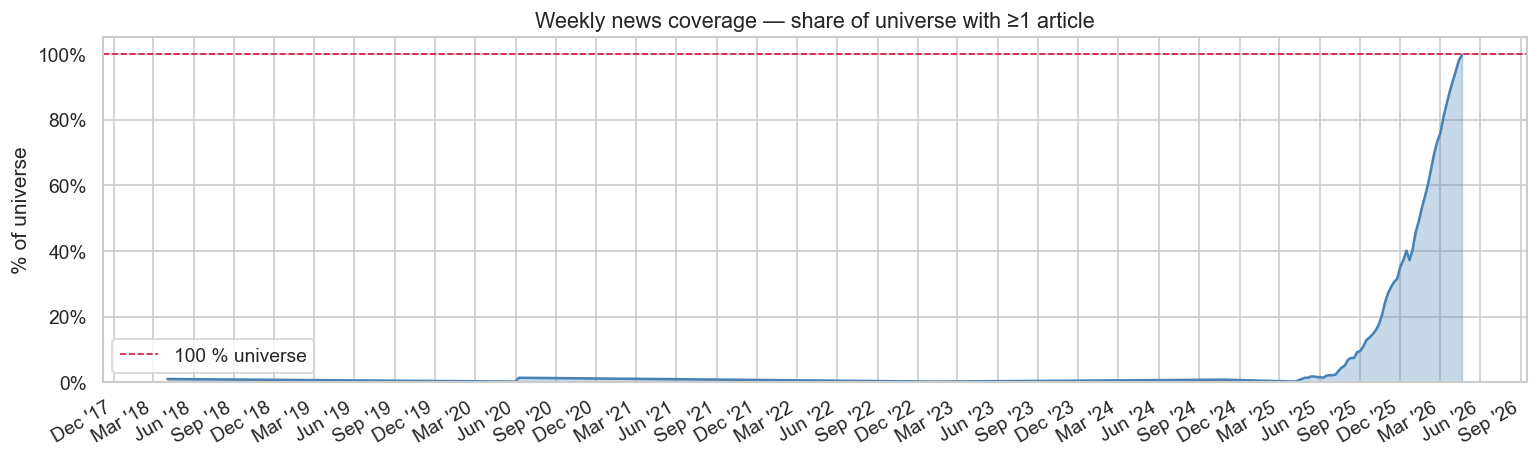


Most-recent 8 weeks:


,week,tickers_with_news,coverage_pct
50,2026-03-02,390,75.9 %
51,2026-03-09,415,80.7 %
52,2026-03-16,435,84.6 %
53,2026-03-23,454,88.3 %
54,2026-03-30,471,91.6 %
55,2026-04-06,487,94.7 %
56,2026-04-13,504,98.1 %
57,2026-04-20,512,99.6 %


In [4]:
covered_weekly = (
    df.groupby("week")["ticker"]
    .nunique()
    .rename("tickers_with_news")
    .reset_index()
)
covered_weekly["coverage_pct"] = (
    covered_weekly["tickers_with_news"] / UNIVERSE_SIZE * 100
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(
    covered_weekly["week"],
    covered_weekly["coverage_pct"],
    alpha=0.3,
    color="steelblue",
)
ax.plot(
    covered_weekly["week"],
    covered_weekly["coverage_pct"],
    color="steelblue",
    lw=1.5,
)
ax.axhline(100, color="crimson", lw=1, ls="--", label="100 % universe")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_title("Weekly news coverage — share of universe with ≥1 article", fontsize=13)
ax.set_ylabel("% of universe")
ax.legend()
plt.tight_layout()
plt.show()

print("\nMost-recent 8 weeks:")
covered_weekly.tail(8)[["week", "tickers_with_news", "coverage_pct"]].assign(
    coverage_pct=lambda d: d["coverage_pct"].round(1).astype(str) + " %"
)

### Coverage rate — daily view (recent 90 days)

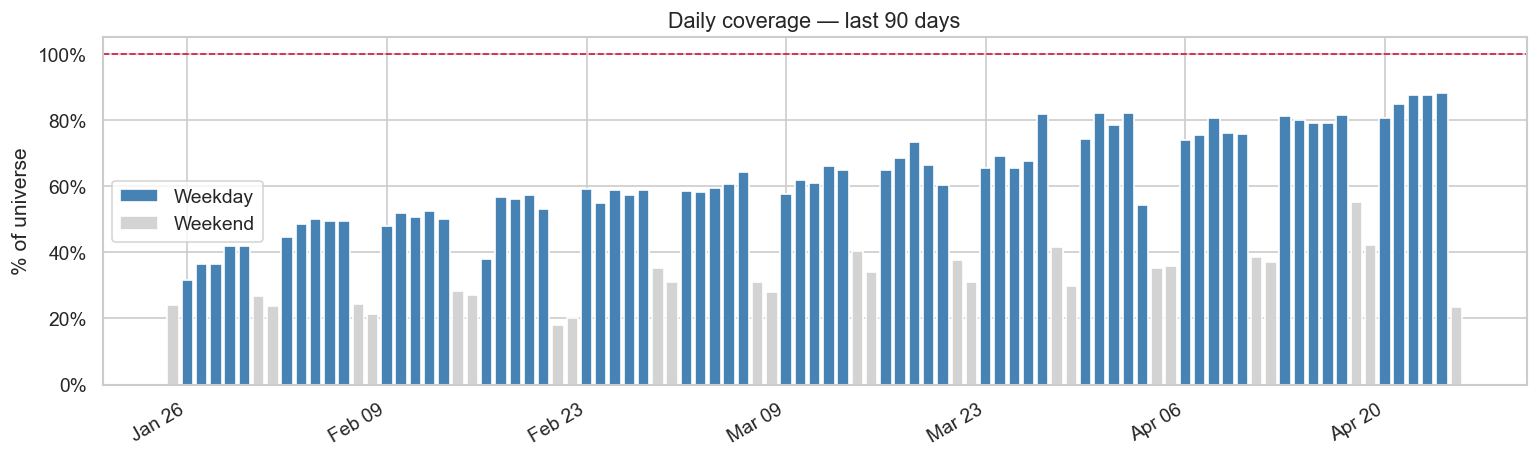

In [5]:
cutoff = df["date"].max() - pd.Timedelta(days=90)
covered_daily = (
    df[df["date"] >= cutoff]
    .groupby("date")["ticker"]
    .nunique()
    .rename("tickers_with_news")
    .reset_index()
)
covered_daily["coverage_pct"] = covered_daily["tickers_with_news"] / UNIVERSE_SIZE * 100
# Mark weekends (no trading → low coverage expected)
covered_daily["is_weekend"] = pd.to_datetime(covered_daily["date"]).dt.dayofweek >= 5

fig, ax = plt.subplots(figsize=(13, 4))
weekdays = covered_daily[~covered_daily["is_weekend"]]
weekends = covered_daily[covered_daily["is_weekend"]]
ax.bar(weekdays["date"], weekdays["coverage_pct"], color="steelblue", width=0.8, label="Weekday")
ax.bar(weekends["date"], weekends["coverage_pct"], color="lightgray", width=0.8, label="Weekend")
ax.axhline(100, color="crimson", lw=1, ls="--")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_title("Daily coverage — last 90 days", fontsize=13)
ax.set_ylabel("% of universe")
ax.legend()
plt.tight_layout()
plt.show()

## 3  Article Volume Over Time

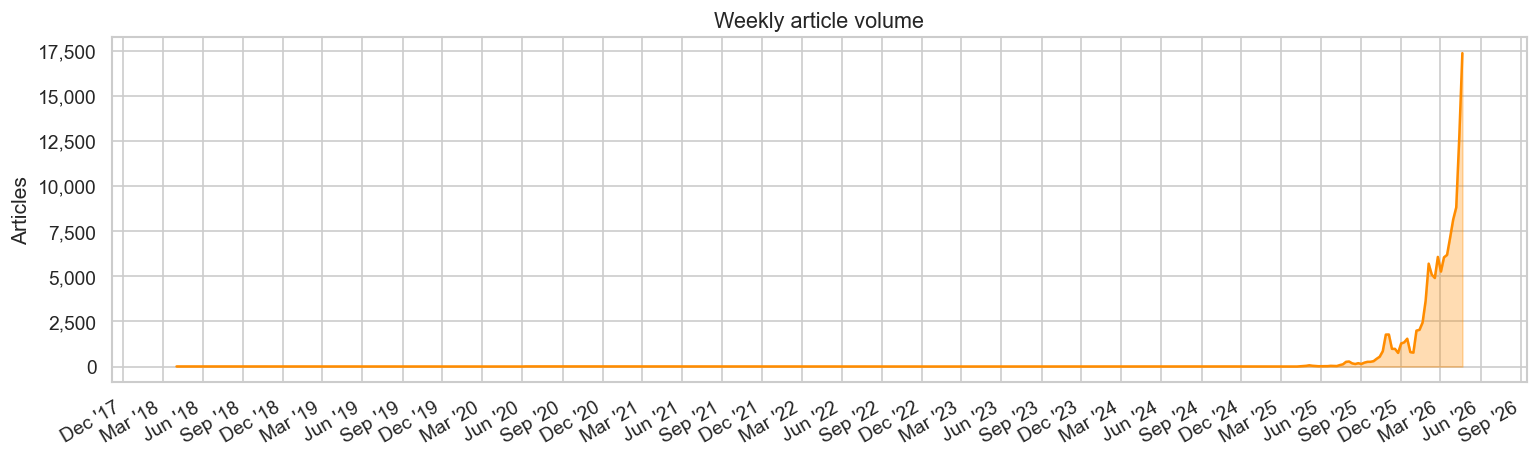

In [6]:
weekly_vol = df.groupby("week").size().rename("articles").reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(weekly_vol["week"], weekly_vol["articles"], alpha=0.3, color="darkorange")
ax.plot(weekly_vol["week"], weekly_vol["articles"], color="darkorange", lw=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_title("Weekly article volume", fontsize=13)
ax.set_ylabel("Articles")
plt.tight_layout()
plt.show()

## 4  Free-Tier Date Distribution

Finnhub free tier ignores the `_from` parameter — each ticker returns its ~245 most recent articles.  
This plot shows how old the oldest article per ticker goes, and the distribution of article dates overall.

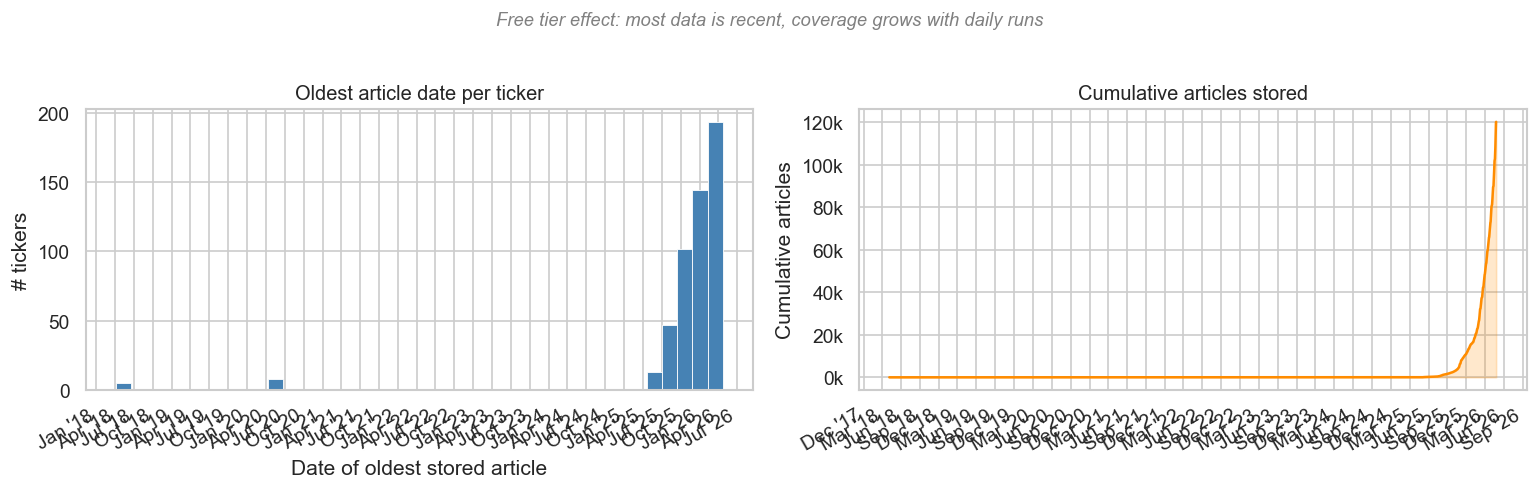

Articles by year:


,articles
year,
2018,5
2020,8
2023,1
2024,4
2025,16302
2026,103954


In [7]:
oldest_per_ticker = df.groupby("ticker")["date"].min()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: distribution of oldest article date per ticker
axes[0].hist(
    oldest_per_ticker,
    bins=40,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")
axes[0].set_title("Oldest article date per ticker", fontsize=12)
axes[0].set_xlabel("Date of oldest stored article")
axes[0].set_ylabel("# tickers")

# Right: cumulative volume by date
daily_vol = df.groupby("date").size().sort_index().cumsum().reset_index()
daily_vol.columns = ["date", "cumulative"]
axes[1].plot(daily_vol["date"], daily_vol["cumulative"], color="darkorange", lw=1.5)
axes[1].fill_between(daily_vol["date"], daily_vol["cumulative"], alpha=0.2, color="darkorange")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[1].set_title("Cumulative articles stored", fontsize=12)
axes[1].set_ylabel("Cumulative articles")

plt.suptitle(
    "Free tier effect: most data is recent, coverage grows with daily runs",
    fontsize=11, y=1.02, style="italic", color="gray"
)
plt.tight_layout()
plt.show()

print("Articles by year:")
df["year"] = df["datetime"].dt.year
df.groupby("year").size().rename("articles").to_frame()

## 5  Source Breakdown

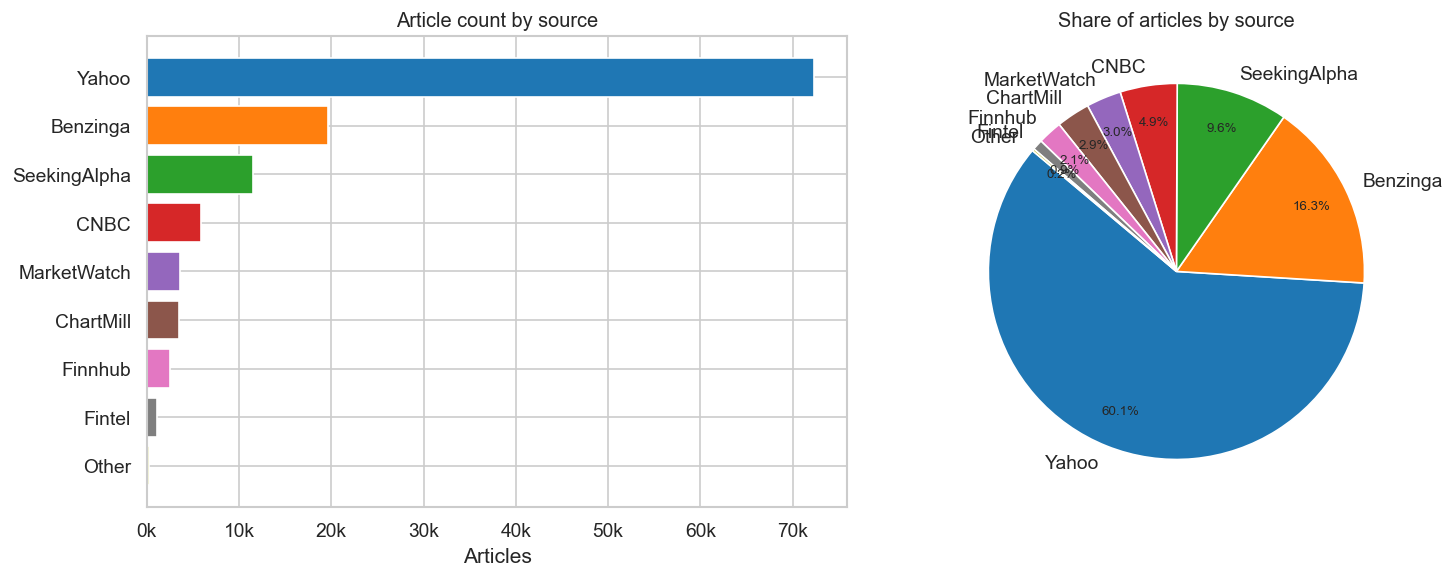

In [8]:
source_counts = df["source"].value_counts()
top_n = 8
top_sources = source_counts.iloc[:top_n]
other = source_counts.iloc[top_n:].sum()
plot_data = pd.concat([top_sources, pd.Series({"Other": other})])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar
colors = sns.color_palette("tab10", len(plot_data))
axes[0].barh(plot_data.index[::-1], plot_data.values[::-1], color=colors[::-1])
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
axes[0].set_title("Article count by source", fontsize=12)
axes[0].set_xlabel("Articles")

# Pie
wedges, texts, autotexts = axes[1].pie(
    plot_data.values,
    labels=plot_data.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    pctdistance=0.8,
)
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title("Share of articles by source", fontsize=12)

plt.tight_layout()
plt.show()

## 6  Summary Null Rate by Source

Some publishers don't provide a summary. Knowing which sources are unreliable  
for downstream NLP is important before building sentiment features.

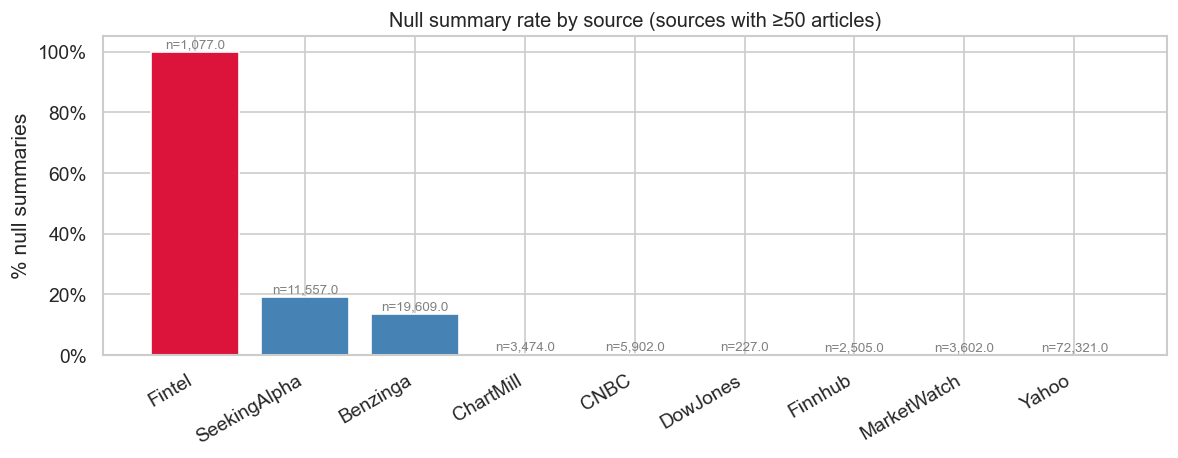

,n,null_pct
source,,
Fintel,"1,077",100.0%
SeekingAlpha,"11,557",19.3%
Benzinga,"19,609",13.6%
ChartMill,"3,474",0.5%
CNBC,"5,902",0.4%
DowJones,227,0.0%
Finnhub,"2,505",0.0%
MarketWatch,"3,602",0.0%
Yahoo,"72,321",0.0%


In [9]:
null_by_source = (
    df.groupby("source")
    .agg(n=("article_id", "count"), null_pct=("summary", lambda s: s.isna().mean() * 100))
    .query("n >= 50")
    .sort_values("null_pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    null_by_source.index,
    null_by_source["null_pct"],
    color=["crimson" if p > 20 else "steelblue" for p in null_by_source["null_pct"]],
)
ax.set_ylabel("% null summaries")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Null summary rate by source (sources with ≥50 articles)", fontsize=12)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

for bar, (src, row) in zip(bars, null_by_source.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"n={row['n']:,}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray",
    )

plt.tight_layout()
plt.show()

null_by_source.style.format({"null_pct": "{:.1f}%", "n": "{:,}"})

## 7  Publication Patterns — Hour of Day & Day of Week

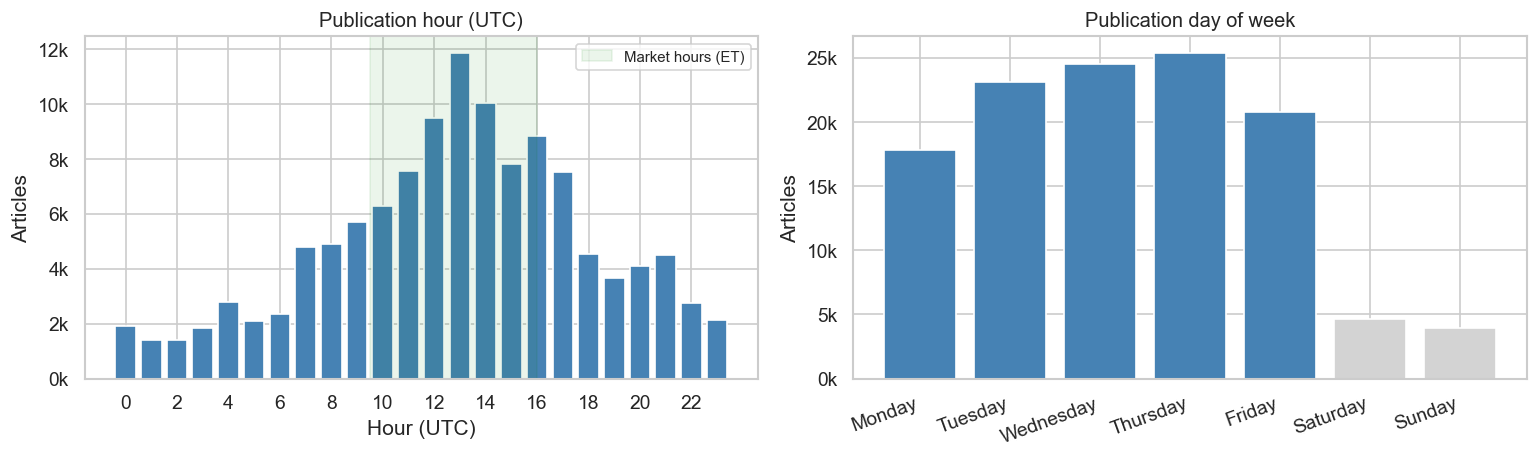

In [10]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hour of day
hour_counts = df["hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color="steelblue", edgecolor="white")
axes[0].axvspan(9.5, 16, alpha=0.08, color="green", label="Market hours (ET)")
axes[0].set_xlabel("Hour (UTC)")
axes[0].set_ylabel("Articles")
axes[0].set_title("Publication hour (UTC)", fontsize=12)
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Day of week
dow_counts = df["dow"].value_counts().reindex(dow_order)
bar_colors = ["lightgray" if d in ("Saturday", "Sunday") else "steelblue" for d in dow_order]
axes[1].bar(dow_counts.index, dow_counts.values, color=bar_colors, edgecolor="white")
axes[1].set_ylabel("Articles")
axes[1].set_title("Publication day of week", fontsize=12)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

plt.tight_layout()
plt.show()

### Hour × Day-of-Week heatmap

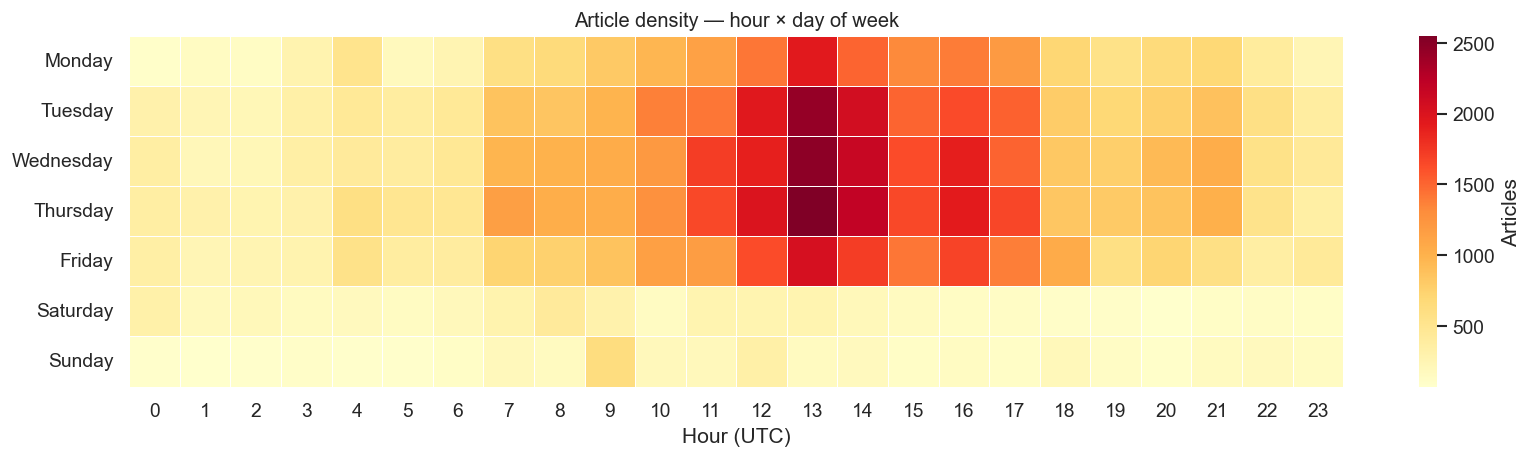

In [11]:
heatmap_data = (
    df.groupby(["dow", "hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    fmt="d",
    cbar_kws={"label": "Articles"},
)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("")
ax.set_title("Article density — hour × day of week", fontsize=12)
plt.tight_layout()
plt.show()

## 8  Headline Length Distribution

/var/folders/qg/gpxytdf13f54gy5xfz2m7v2r0000gp/T/ipykernel_71355/1009708170.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


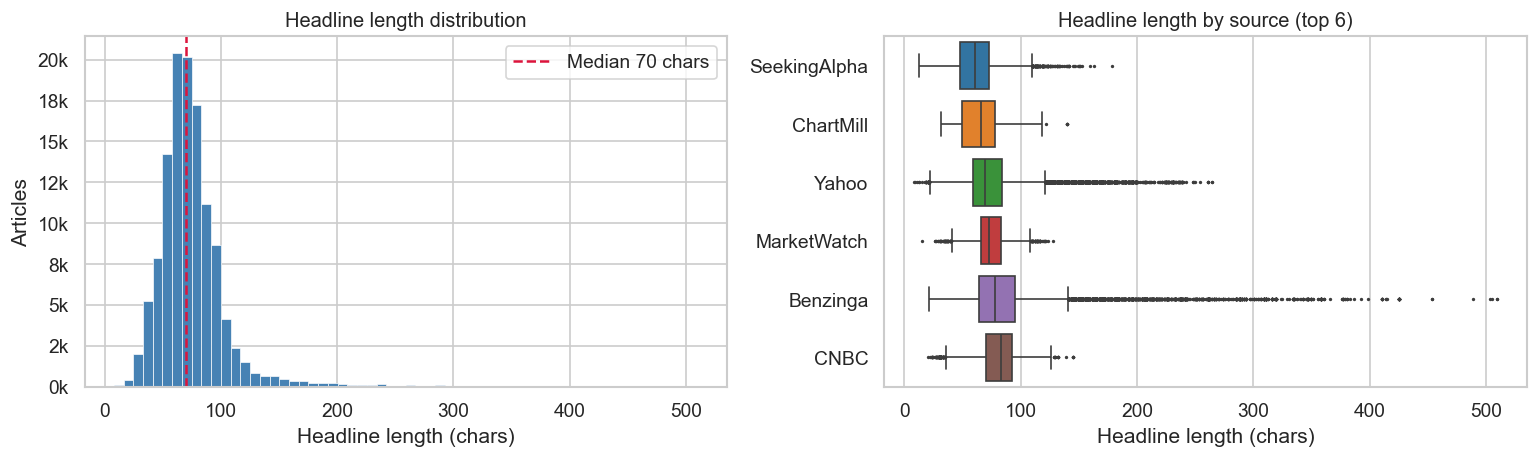


Headline length stats:


,headline_len
count,120274.0
mean,74.8
std,30.3
min,8.0
25%,59.0
50%,70.0
75%,85.0
max,510.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall distribution
axes[0].hist(
    df["headline_len"],
    bins=60,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4,
)
axes[0].axvline(
    df["headline_len"].median(),
    color="crimson",
    ls="--",
    label=f"Median {df['headline_len'].median():.0f} chars",
)
axes[0].set_xlabel("Headline length (chars)")
axes[0].set_ylabel("Articles")
axes[0].set_title("Headline length distribution", fontsize=12)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# By source (top 6)
top6 = source_counts.iloc[:6].index.tolist()
df_top6 = df[df["source"].isin(top6)]
source_order = (
    df_top6.groupby("source")["headline_len"]
    .median()
    .sort_values()
    .index.tolist()
)
sns.boxplot(
    data=df_top6,
    x="headline_len",
    y="source",
    order=source_order,
    ax=axes[1],
    palette="tab10",
    flierprops={"marker": ".", "markersize": 2},
)
axes[1].set_xlabel("Headline length (chars)")
axes[1].set_ylabel("")
axes[1].set_title("Headline length by source (top 6)", fontsize=12)

plt.tight_layout()
plt.show()

print("\nHeadline length stats:")
df["headline_len"].describe().round(1).to_frame()

## 9  Tickers with Poorest Coverage

Which tickers have fewest articles (potential gaps for signal generation)?

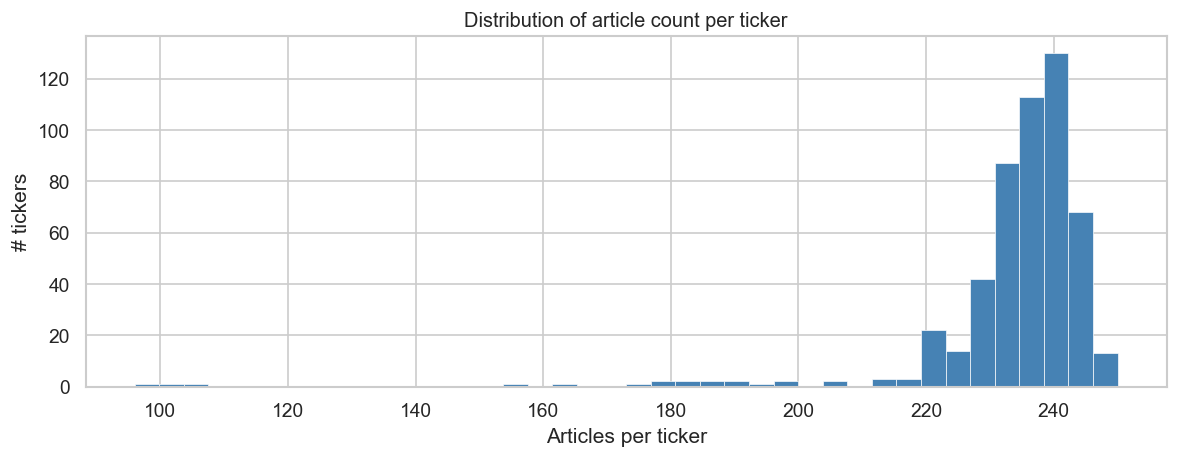

Tickers with fewest articles:


,ticker,n_articles,oldest,newest,n_sources,null_summary_pct
191,FER,96,2025-05-13 00:00:00,2026-04-17 00:00:00,3,12.5%
83,CCEP,103,2025-04-30 00:00:00,2026-04-24 00:00:00,4,4.9%
280,L,106,2025-04-30 00:00:00,2026-04-15 00:00:00,7,3.8%
117,CRH,156,2025-11-12 00:00:00,2026-04-22 00:00:00,9,11.5%
229,HII,164,2026-02-12 00:00:00,2026-04-24 00:00:00,9,9.8%
247,IFF,176,2025-10-14 00:00:00,2026-04-24 00:00:00,7,5.7%
172,ERIE,177,2025-05-01 00:00:00,2026-04-25 00:00:00,7,5.6%
497,WMB,180,2026-01-29 00:00:00,2026-04-24 00:00:00,8,12.2%
215,GNRC,182,2026-01-19 00:00:00,2026-04-24 00:00:00,8,6.6%
322,MRSH,183,2026-01-14 00:00:00,2026-04-25 00:00:00,6,3.8%


In [13]:
coverage_df = (
    df.groupby("ticker")
    .agg(
        n_articles=("article_id", "count"),
        oldest=("date", "min"),
        newest=("date", "max"),
        n_sources=("source", "nunique"),
        null_summary_pct=("summary", lambda s: s.isna().mean() * 100),
    )
    .reset_index()
    .sort_values("n_articles")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    coverage_df["n_articles"],
    bins=40,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel("Articles per ticker")
ax.set_ylabel("# tickers")
ax.set_title("Distribution of article count per ticker", fontsize=12)
plt.tight_layout()
plt.show()

print("Tickers with fewest articles:")
coverage_df.head(15).style.format(
    {"null_summary_pct": "{:.1f}%", "n_articles": "{:,}"}
)